# 任务B：三分类（灰色 Grey vs 黄色 Yellow vs 蓝色 Blue）

In [11]:
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models
from matplotlib import pyplot as plt
import torchvision.transforms as T
import os
from PIL import Image
import time
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# 配置信息
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"训练设备: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

训练设备: cuda:0
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 可视化函数

In [12]:
def plot_curves(loss_data, acc_data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(loss_data, 'b-', label='Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(acc_data, 'g-', label='Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

In [13]:
def plot_image(img, label, name):
    fig = plt.figure(figsize=(10, 4))
    img = img.detach().numpy()
    labels = ['Grey', 'Yellow', 'Blue']
    for i in range(min(4, len(img))):
        plt.subplot(1, 4, i + 1)
        plt.imshow(img[i].transpose(1,2,0))
        plt.title(f"{name}: {labels[label[i].item()]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## 数据集定义

In [14]:
class MyDataset(Dataset):
    def __init__(self, flag='train'):
        self.flag = flag
        self.Animedata_path = []
        
        # 使用data目录，三分类：Grey、Yellow和Blue
        if flag == 'train':
            base = "./data/train"
        else:
            base = "./data/test"
        
        # Grey(0), Yellow(1), Blue(2) 三分类
        for i in os.listdir(os.path.join(base, "grey")):
            self.Animedata_path.append((os.path.join(base, "grey", i), 0))
        for i in os.listdir(os.path.join(base, "yellow")):
            self.Animedata_path.append((os.path.join(base, "yellow", i), 1))
        for i in os.listdir(os.path.join(base, "blue")):
            self.Animedata_path.append((os.path.join(base, "blue", i), 2))
        
        # 数据增强
        if flag == 'train':
            self.transforms = T.Compose([
                T.Resize((112, 112)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(15),
                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        else:
            self.transforms = T.Compose([
                T.Resize((112, 112)),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
            
    def __getitem__(self, index):
        path, label = self.Animedata_path[index]
        image = Image.open(path)
        image = self.transforms(image)
        return image, label
    
    def __len__(self):
        return len(self.Animedata_path)

## 数据加载

训练集样本数: 44642
测试集样本数: 11099
Batch size: 64


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


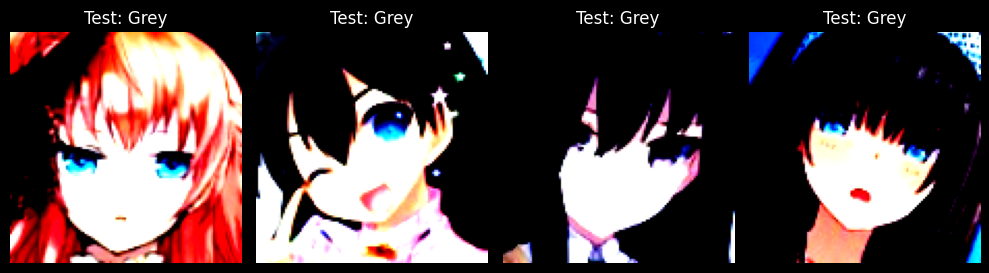

In [15]:
batch_size = 64

train_loader = DataLoader(
    MyDataset(flag='train'),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
test_loader = DataLoader(
    MyDataset(flag='test'),
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"训练集样本数: {len(train_loader.dataset)}")
print(f"测试集样本数: {len(test_loader.dataset)}")
print(f"Batch size: {batch_size}")

# 显示样本图片
x, y = next(iter(test_loader))
plot_image(x, y, "Test")

## 模型定义 - 使用预训练ResNet18

In [16]:
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CNN, self).__init__()
        
        # 使用预训练ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # 去掉最后全连接层
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        
        # 冻结卷积层参数
        for param in self.features.parameters():
            param.requires_grad = False
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net = CNN(num_classes=3).to(device)
print(f"模型参数量: {sum(p.numel() for p in net.parameters()):,}")
print(f"可训练参数量: {sum(p.numel() for p in net.parameters() if p.requires_grad):,}")

模型参数量: 11,309,635
可训练参数量: 133,123


## 优化器与损失函数

In [17]:
optimizer = optim.AdamW(net.classifier.parameters(), lr=0.0001, weight_decay=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
criterion = nn.CrossEntropyLoss()

print("优化器: AdamW")
print("损失函数: CrossEntropyLoss")
print("分类类别: Grey, Yellow, Blue (3类)")

优化器: AdamW
损失函数: CrossEntropyLoss
分类类别: Grey, Yellow, Blue (3类)


## 训练

In [18]:
from tqdm import tqdm

train_loss = []
train_acc = []
val_acc = []
best_acc = 0.0
num_epochs = 15

start_time = time.time()

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = net(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
        
        pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{100.*correct/total:.1f}%")
    
    pbar.close()
    scheduler.step()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)
    
    # 验证
    net.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = net(x)
            pred = outputs.argmax(dim=1)
            val_correct += pred.eq(y).sum().item()
            val_total += y.size(0)
    
    val_acc_epoch = 100. * val_correct / val_total
    val_acc.append(val_acc_epoch)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Train: {epoch_acc:.2f}% | Val: {val_acc_epoch:.2f}% | Time: {elapsed:.1f}s")
    
    if val_acc_epoch > best_acc:
        best_acc = val_acc_epoch
        torch.save(net.state_dict(), 'best_model_three.pth')
        print(f"  -> 保存最佳模型!")

print(f"\n训练完成! 最佳验证准确率: {best_acc:.2f}%")

Epoch 1 | Loss: 0.9195 | Train: 56.31% | Val: 62.08% | Time: 17.4s
  -> 保存最佳模型!


Epoch 2 | Loss: 0.8584 | Train: 60.85% | Val: 62.60% | Time: 34.3s
  -> 保存最佳模型!


Epoch 3 | Loss: 0.8487 | Train: 61.19% | Val: 63.56% | Time: 50.9s
  -> 保存最佳模型!


Epoch 4 | Loss: 0.8462 | Train: 61.32% | Val: 63.91% | Time: 67.5s
  -> 保存最佳模型!


Epoch 5 | Loss: 0.8406 | Train: 61.66% | Val: 63.75% | Time: 84.0s


...

Epoch 11 | Loss: 0.8275 | Train: 62.29% | Val: 64.14% | Time: 183.4s
  -> 保存最佳模型!


Epoch 12 | Loss: 0.8326 | Train: 61.85% | Val: 64.00% | Time: 200.4s


Epoch 13 | Loss: 0.8314 | Train: 62.09% | Val: 63.86% | Time: 217.9s


Epoch 14 | Loss: 0.8301 | Train: 62.16% | Val: 64.05% | Time: 234.5s


Epoch 15 | Loss: 0.8258 | Train: 62.11% | Val: 63.89% | Time: 251.7s

训练完成! 最佳验证准确率: 64.14%


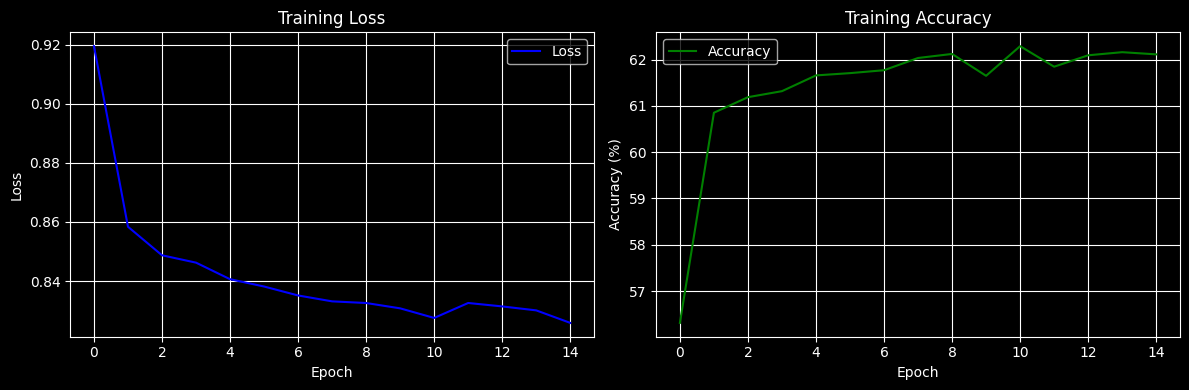

In [19]:
plot_curves(train_loss, train_acc)

## 测试


测试集准确率: 64.14%
正确分类: 7119/11099


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


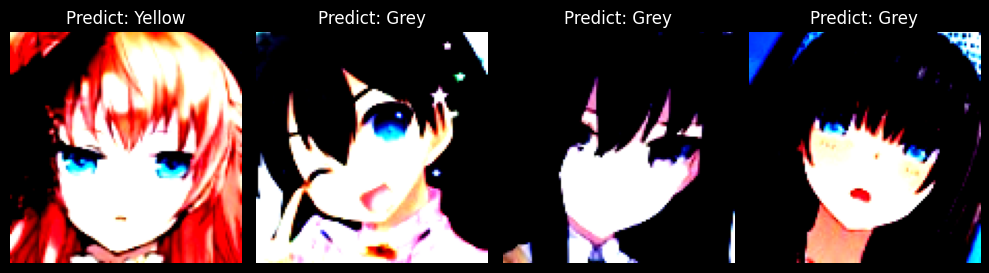

In [20]:
# 加载最佳模型
net.load_state_dict(torch.load('best_model_three.pth', weights_only=True))
net.eval()

total_correct = 0
total_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = net(x)
        pred = outputs.argmax(dim=1)
        total_correct += pred.eq(y).sum().item()
        total_samples += y.size(0)

acc = total_correct / total_samples
print(f'\n测试集准确率: {acc*100:.2f}%')
print(f'正确分类: {total_correct}/{total_samples}')

# 显示预测结果
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)
out = net(x)
pred = out.argmax(dim=1)
plot_image(x.cpu(), pred.cpu(), 'Predict')